In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set random seed for reproducibility
np.random.seed(33)

In [3]:
# Generate z as an alternating Bernoulli sequence
n = 20
# z = np.random.randint(0, 2, size=n)
z = np.random.randint(0, 2, size=n) * 2 - 1

In [4]:
print(z)

[-1  1 -1 -1 -1  1  1  1 -1  1  1 -1 -1 -1  1  1  1  1  1 -1]


In [18]:
# 1 generate x and y depending on z （simplest, no noise, global)
x, y = np.zeros(n), np.zeros(n)  # 初始化x和y数组

for i in range(n):
    if z[i] == 1:
        # 正相关：x和y基于同一个基础值base，无噪声
        base = np.random.normal(0, 1)  # 基础值（均值0，标准差1的正态分布）
        x[i] = base  # x直接等于base（无噪声）
        y[i] = base  # y直接等于base（无噪声，与x正相关）
    else:
        # 负相关：x基于base，y基于-base，无噪声
        base = np.random.normal(0, 1)  # 基础值
        x[i] = base  # x直接等于base
        y[i] = -base  # y等于-base（与x负相关）

In [38]:
# generate x and y depending on z （no noise, local)
x, y = np.zeros(n), np.zeros(n)  # 初始化x和y数组

corr_start, corr_end = 3, 10 # 在（3，10）以外的区间非随机

for i in range(n):
    if corr_start <= i <= corr_end:
        # 区间内：使用版本1的正负相关逻辑（无噪声）
        if z[i] == 1:
            base = np.random.normal(0, 1)
            x[i] = base
            y[i] = base  # 正相关
        else:
            base = np.random.normal(0, 1)
            x[i] = base
            y[i] = -base # 负相关
    else:
        # 区间外：x和y完全随机，无相关性
        x[i] = np.random.normal(0, 1)  # 随机值
        y[i] = np.random.normal(0, 1)  # 随机值（与x无关）

In [ ]:
# with noise
# Generate x and y depending on z
x, y = np.zeros(n), np.zeros(n)
for i in range(n):
    if z[i] == 1:
        # positive local correlation
        base = np.random.normal(0, 1)
        noise = np.random.normal(0, 0.3)
        x[i] = base + np.random.normal(0, 0.2)
        y[i] = base + noise
    else:
        # negative local correlation
        base = np.random.normal(0, 1)
        noise = np.random.normal(0, 0.3)
        x[i] = base + np.random.normal(0, 0.2)
        y[i] = -base + noise

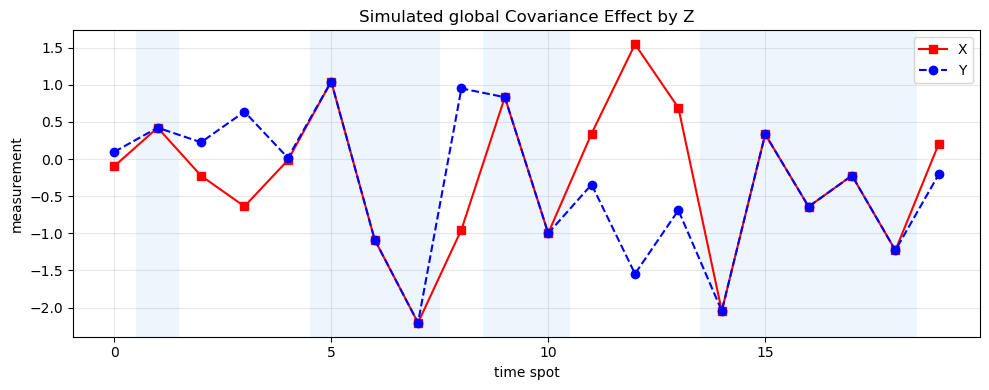

In [22]:
# Visualization for 1
time = np.arange(n)
plt.figure(figsize=(10,4))
plt.plot(time, x, 'r-s', label='X')
plt.plot(time, y, 'b--o', label='Y')

# Shade regions where z == 1
for i in range(n):
    if z[i] == 1:
        plt.axvspan(i-0.5, i+0.5, color='#84C4EF', alpha=0.15, linewidth=0)

plt.xticks(np.arange(0, n, 5))  # 只显示0,5,10,15,20
plt.xlabel('time spot')
plt.ylabel('measurement')
plt.title('Simulated global Covariance Effect by Z')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


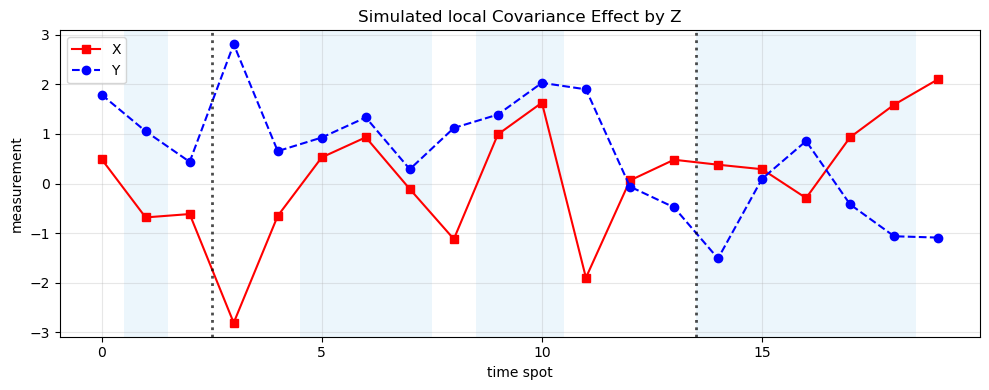

In [ ]:
# visualization for 2
from matplotlib.patches import Rectangle 

time = np.arange(n)
plt.figure(figsize=(10,4))
plt.plot(time, x, 'r-s', label='X')
plt.plot(time, y, 'b--o', label='Y')

# Shade regions where z == 1
for i in range(n):
    if z[i] == 1:
        plt.axvspan(i-0.5, i+0.5, color='#84C4EF', alpha=0.15, linewidth=0)

plt.axvline(corr_start-0.5, color='k', linestyle=':', lw=2, alpha=0.7) # 用竖线突出local区域
plt.axvline(corr_end+0.5, color='k', linestyle=':', lw=2, alpha=0.7)

plt.xticks(np.arange(0, n, 5))
plt.xlabel('time spot')
plt.ylabel('measurement')
plt.title('Simulated local Covariance Effect by Z')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
print(x * y * z)

[-1.33782166e-01 -6.09605176e-01  6.89421197e-01  1.07599624e-02
  2.59351466e-02  8.00203590e-01  1.66602755e+00  1.16911894e-02
  2.95364203e-03  5.05407870e-01  6.07473587e+00 -2.11077859e+00
  1.14518762e-01  2.11638507e-01  1.08958972e-01 -4.49310983e-01
 -1.04235412e-03 -3.82867371e-02 -1.10794517e-01  8.94905105e-01]


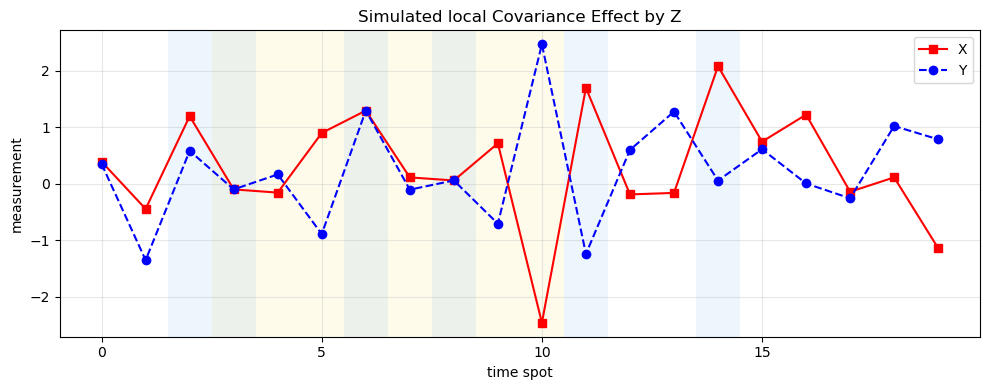

In [40]:
# visualization for 2
# 图中淡蓝色竖条表示 Bernoulli 变量 z=1 的时刻，金色背景区域为人为设定的相关区间（time 3–13）

time = np.arange(n)
plt.figure(figsize=(10,4))
plt.plot(time, x, 'r-s', label='X')
plt.plot(time, y, 'b--o', label='Y')

plt.axvspan(corr_start-0.5, corr_end+0.5,
            color='gold', alpha=0.08, linewidth=0, zorder=-1) # 用阴影突出有作用的区域

# Shade regions where z == 1
for i in range(n):
    if z[i] == 1:
        plt.axvspan(i-0.5, i+0.5, color='#84C4EF', alpha=0.15, linewidth=0)


plt.xticks(np.arange(0, n, 5))
plt.xlabel('time spot')
plt.ylabel('measurement')
plt.title('Simulated local Covariance Effect by Z')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
##

plt.figure(figsize=(12, 10))  # 整体画布

# 子图1：时间序列图（展示x,y随时间的变化，突出z的分组）
plt.subplot(2, 2, 1)  # 2行2列，第1个位置
time = np.arange(n)

# 分别绘制z=0和z=1时的x、y，用不同标记区分
plt.plot(time[z==1], x[z==1], 'r-s', label='X (z=1)', markersize=6)
plt.plot(time[z==1], y[z==1], 'b--o', label='Y (z=1)', markersize=6)
plt.plot(time[z==0], x[z==0], 'g-s', label='X (z=0)', markersize=6)
plt.plot(time[z==0], y[z==0], 'm--o', label='Y (z=0)', markersize=6)

# 用背景色区分z=0/1的区间（更醒目）
for i in range(n):
    if z[i] == 1:
        plt.axvspan(i-0.5, i+0.5, color='pink', alpha=0.3)  # z=1用粉色
    else:
        plt.axvspan(i-0.5, i+0.5, color='lightblue', alpha=0.3)  # z=0用浅蓝色

plt.xlabel('Time spot')
plt.ylabel('Value')
plt.title('X and Y over Time (z=1: pink, z=0: blue)')
plt.legend()
plt.grid(alpha=0.3)

# 子图2：z=1时x和y的散点图+回归线（正相关）
plt.subplot(2, 2, 2)
mask_z1 = (z == 1)
plt.scatter(x[mask_z1], y[mask_z1], color='red', label='z=1', s=50)

# 计算并绘制回归线
slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask_z1], y[mask_z1])
plt.plot(x[mask_z1], intercept + slope*x[mask_z1], 'r--')  # 回归线
plt.text(min(x[mask_z1]), max(y[mask_z1]), f'R = {r_value:.2f}', color='red')  # 相关系数

plt.xlabel('X value')
plt.ylabel('Y value')
plt.title('X vs Y when z=1 (Positive Correlation)')
plt.legend()
plt.grid(alpha=0.3)

# 子图3：z=0时x和y的散点图+回归线（负相关）
plt.subplot(2, 2, 4)
mask_z0 = (z == 0)
plt.scatter(x[mask_z0], y[mask_z0], color='blue', label='z=0', s=50)

# 计算并绘制回归线
slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask_z0], y[mask_z0])
plt.plot(x[mask_z0], intercept + slope*x[mask_z0], 'b--')  # 回归线
plt.text(min(x[mask_z0]), max(y[mask_z0]), f'R = {r_value:.2f}', color='blue')  # 相关系数

plt.xlabel('X value')
plt.ylabel('Y value')
plt.title('X vs Y when z=0 (Negative Correlation)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()  # 自动调整布局
plt.show()